(537, 691, 3)


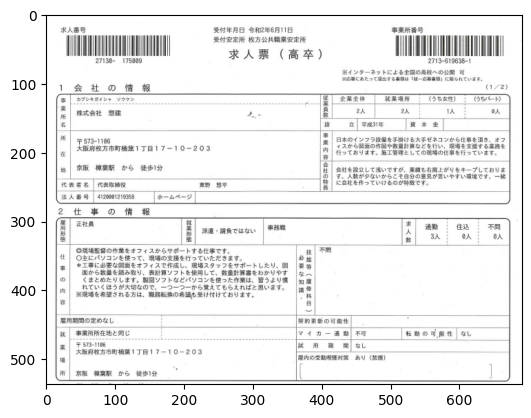

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r"C:\Users\ASUS\ML-in-Prod-batch-2\3_Image_Processing_Techniques\MyLearning\OCR\OCR_proj\configs\image.png"
input_image = cv2.imread(img_path)
print(input_image.shape)
plt.imshow(input_image)

## OCR Starts


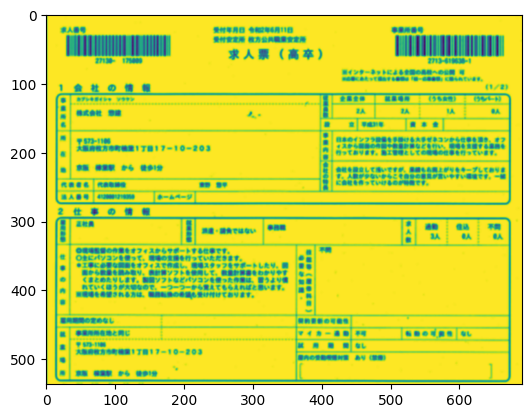

In [5]:
img =  input_image.copy()

#Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# plt.imshow(img )

#Make GaussianBlur (Normalized the colors)
blurred = cv2.GaussianBlur(img, (5, 5), 0)
plt.imshow(blurred)



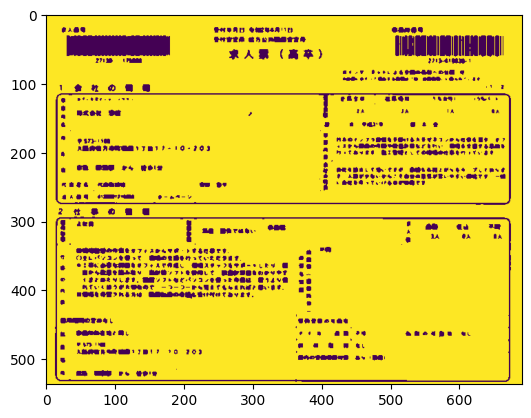

In [14]:
#Perform the thresholding (Weak links are disapper)

thresh = cv2.threshold(blurred,200,255, cv2.THRESH_BINARY)[1]
plt.imshow(thresh)

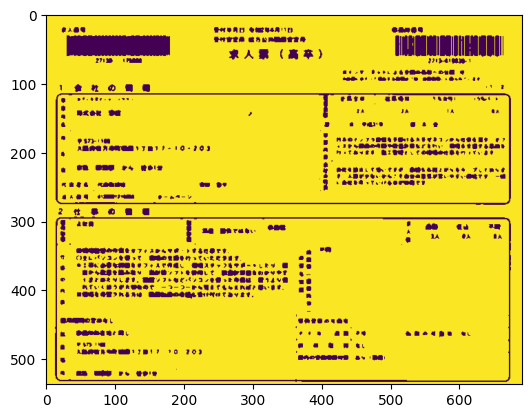

In [15]:
#perform the bilitreal filter
gray = cv2.bilateralFilter(thresh, 1,100,150)
plt.imshow(gray)

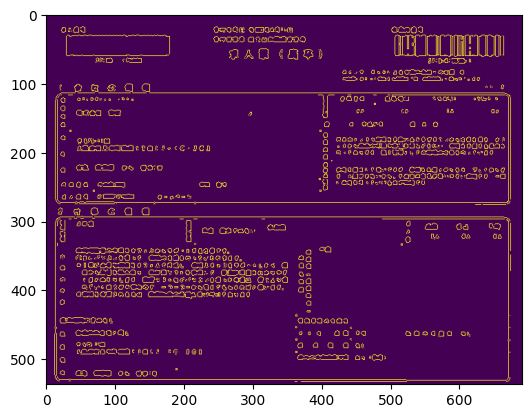

In [16]:
imgTheshold = cv2.Canny(thresh,20,250)
plt.imshow(imgTheshold)

In [17]:
def reorder(myPoints):
    myPoints = myPoints.reshape((4, 2))
    myPointsNew = np.zeros((4, 1, 2), dtype=np.int32)
    add = myPoints.sum(1)

    myPointsNew[0] = myPoints[np.argmin(add)]
    myPointsNew[3] = myPoints[np.argmax(add)]
    diff = np.diff(myPoints, axis=1)
    myPointsNew[1] = myPoints[np.argmin(diff)]
    myPointsNew[2] = myPoints[np.argmax(diff)]

    return myPointsNew


##### What are contours?
Contours can be explained simply as a curve joining all the continuous points (along the boundary), having same color or intensity. The contours are a useful tool for shape analysis and object detection and recognition.

In [ ]:

# FIND ALL CONTOURS
contours, hierarchy = cv2.findContours(imgTheshold, cv2.CHAIN_APPROX_SIMPLE)

rgb = img.copy()
rect_list = []

for i in contours:
    area = cv2.contourArea(i)

    if area > 8000:
        peri = cv2.arcLength(i, True)

        approx = cv2.approxPolyDP(i, 0.02 * peri, True)
        if len(approx) == 4:

            cv2.drawContours(rgb, [approx], -1, (0, 255, 0), 2)
            print(approx[:4])
            print()
            rect_list.append(reorder(approx[:4]))
plt.imshow(rgb)

NameError: name 'EXTERNAL' is not defined